In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("/kaggle/input/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv")

In [15]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [17]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [18]:
df.isna().mean().sort_values(ascending=False)

Sunshine         0.480098
Evaporation      0.431665
Cloud3pm         0.408071
Cloud9am         0.384216
Pressure9am      0.103568
Pressure3pm      0.103314
WindDir9am       0.072639
WindGustDir      0.070989
WindGustSpeed    0.070555
Humidity3pm      0.030984
WindDir3pm       0.029066
Temp3pm          0.024811
RainTomorrow     0.022460
Rainfall         0.022419
RainToday        0.022419
WindSpeed3pm     0.021050
Humidity9am      0.018246
WindSpeed9am     0.012148
Temp9am          0.012148
MinTemp          0.010209
MaxTemp          0.008669
Date             0.000000
Location         0.000000
dtype: float64

<Axes: title={'center': 'Rain Tomorrow % count'}, xlabel='RainTomorrow', ylabel='percent'>

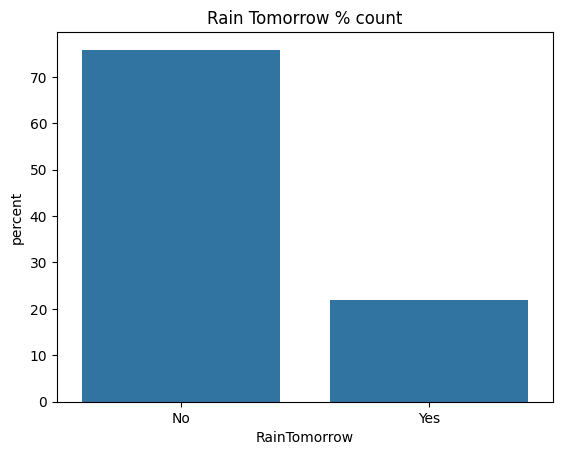

In [19]:
plt.title('Rain Tomorrow % count')
sns.countplot(df, x='RainTomorrow', stat='percent')

In [20]:
df['Month'] = pd.to_datetime(df['Date']).dt.month
df['Season'] = df['Month'].map({12:'Summer', 1:'Summer', 2:'Summer',
                                 3:'Autumn', 4:'Autumn', 5:'Autumn',
                                 6:'Winter', 7:'Winter', 8:'Winter',
                                 9:'Spring', 10:'Spring', 11:'Spring'})
df.drop(columns=['Date'], inplace=True)

In [21]:
df.dropna(subset=['RainTomorrow'], inplace=True)

In [22]:
df[df.isna().any(axis=1)]

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month,Season
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No,12,Summer
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No,12,Summer
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No,12,Summer
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No,12,Summer
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No,12,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,E,...,1024.7,1021.2,NaN,NaN,9.4,20.9,No,No,6,Winter
145455,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,...,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No,6,Winter
145456,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,...,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No,6,Winter
145457,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,...,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No,6,Winter


<Axes: title={'center': 'Sunshine v/s Location'}, xlabel='Sunshine', ylabel='Location'>

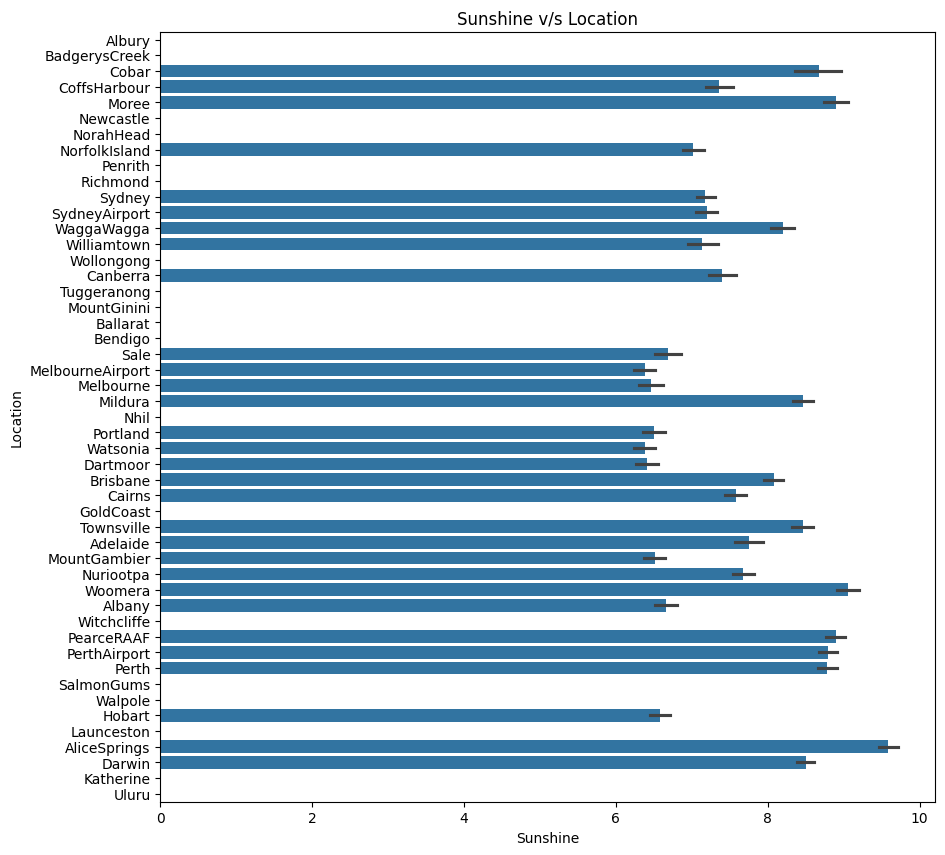

In [23]:
plt.figure(figsize=(10, 10))
plt.title('Sunshine v/s Location')
sns.barplot(df, x = 'Sunshine', y='Location')

<Axes: title={'center': 'Sunshine v/s Evaporation'}, xlabel='Sunshine', ylabel='Evaporation'>

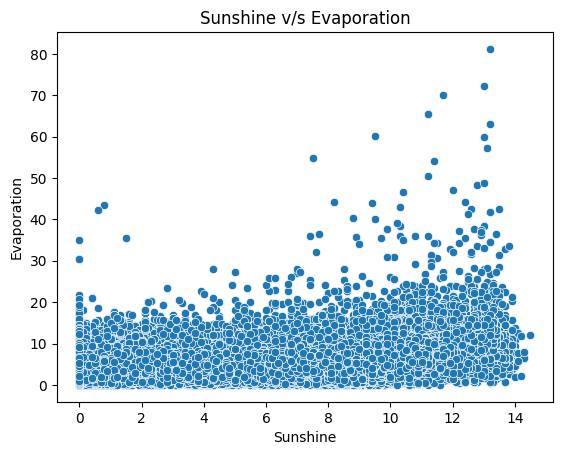

In [24]:
plt.title('Sunshine v/s Evaporation')
sns.scatterplot(df, x = 'Sunshine', y='Evaporation')

In [25]:
loc_profile = df.groupby('Location')[['MaxTemp', 'MinTemp', 'Rainfall', 'Humidity3pm']].median()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
loc_scaled = scaler.fit_transform(loc_profile)

kmeans = KMeans(n_clusters=6, random_state=42)
loc_profile['Cluster'] = kmeans.fit_predict(loc_scaled)

df['Cluster'] = df['Location'].map(loc_profile['Cluster'])

df['Sunshine'] = df.groupby('Cluster')['Sunshine'].transform(
    lambda x: x.fillna(x.median())
)

df['Sunshine'] = df['Sunshine'].fillna(df['Sunshine'].median())

df['Evaporation'] = df.groupby('Cluster')['Evaporation'].transform(
    lambda x: x.fillna(x.median())
)
df['Evaporation'] = df['Evaporation'].fillna(df['Evaporation'].median())

df['Pressure9am'] = df.groupby('Cluster')['Pressure9am'].transform(
    lambda x: x.fillna(x.median())
)
df['Pressure9am'] = df['Pressure9am'].fillna(df['Pressure9am'].median())

df['Pressure3pm'] = df.groupby('Cluster')['Pressure3pm'].transform(
    lambda x: x.fillna(x.median())
)
df['Pressure3pm'] = df['Pressure3pm'].fillna(df['Pressure3pm'].median())

df['Cloud9am'] = df.groupby('Cluster')['Cloud9am'].transform(
    lambda x: x.fillna(x.median())
)
df['Cloud9am'] = df['Cloud9am'].fillna(df['Cloud9am'].median())

df['Cloud3pm'] = df.groupby('Cluster')['Cloud3pm'].transform(
    lambda x: x.fillna(x.median())
)
df['Cloud3pm'] = df['Cloud3pm'].fillna(df['Cloud3pm'].median())


In [26]:
df[df['WindDir9am'].isna() & df['WindSpeed9am'].notna()]

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month,Season,Cluster
26,Albury,16.9,33.0,0.0,3.8,7.3,WSW,57.0,NaN,W,...,1003.6,6.0,1.0,26.6,31.2,No,No,12,Summer,0
65,Albury,21.7,36.9,0.0,3.8,7.3,NaN,NaN,NaN,NaN,...,1004.7,6.0,6.0,25.5,35.2,No,No,2,Summer,0
86,Albury,8.9,31.9,0.0,3.8,7.3,WNW,43.0,NaN,WSW,...,1013.4,7.0,7.0,15.0,29.3,No,No,2,Summer,0
88,Albury,15.4,32.6,0.0,3.8,7.3,W,24.0,NaN,S,...,1012.6,6.0,6.0,20.0,30.8,No,No,2,Summer,0
95,Albury,7.6,24.0,0.0,3.8,7.3,WSW,30.0,NaN,WNW,...,1012.0,6.0,6.0,12.6,22.0,No,No,3,Autumn,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145130,Uluru,5.6,28.7,0.0,6.8,10.0,WNW,39.0,NaN,WNW,...,1014.1,2.0,3.0,13.6,27.9,No,No,7,Winter,3
145169,Uluru,15.1,31.1,0.0,6.8,10.0,WSW,48.0,NaN,W,...,1012.8,8.0,3.0,21.0,30.3,No,No,9,Spring,3
145323,Uluru,25.6,40.6,0.2,6.8,10.0,ENE,56.0,NaN,N,...,1003.2,2.0,1.0,32.0,38.6,No,No,2,Summer,3
145422,Uluru,4.3,22.4,0.0,6.8,10.0,ENE,26.0,NaN,N,...,1014.8,2.0,3.0,10.9,21.3,No,No,5,Autumn,3


In [27]:
df[df['WindDir3pm'].isna() & df['WindSpeed3pm'].notna()]

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month,Season,Cluster
64,Albury,21.5,37.7,0.0,3.8,7.3,NaN,NaN,N,NaN,...,1005.7,6.0,6.0,27.2,36.2,No,No,2,Summer,0
65,Albury,21.7,36.9,0.0,3.8,7.3,NaN,NaN,NaN,NaN,...,1004.7,6.0,6.0,25.5,35.2,No,No,2,Summer,0
75,Albury,12.4,29.2,0.0,3.8,7.3,NE,39.0,S,NaN,...,1016.4,6.0,6.0,18.3,28.5,No,No,2,Summer,0
182,Albury,8.0,14.3,1.2,3.8,7.3,SE,13.0,NaN,NaN,...,1029.2,8.0,8.0,9.2,14.0,Yes,Yes,6,Winter,0
187,Albury,1.7,10.5,0.2,3.8,7.3,ESE,11.0,E,NaN,...,1011.1,8.0,8.0,4.7,10.2,No,Yes,6,Winter,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143273,Katherine,26.0,39.5,0.0,9.6,9.7,WNW,22.0,NaN,NaN,...,1009.0,0.0,4.0,31.5,NaN,No,No,10,Spring,2
143724,Katherine,24.5,33.5,21.8,5.8,9.7,W,52.0,WNW,NaN,...,1006.5,7.0,4.0,28.0,NaN,Yes,Yes,1,Summer,2
144327,Uluru,14.9,27.6,0.0,6.8,10.0,W,28.0,ESE,NaN,...,1017.2,4.0,3.0,18.7,27.0,No,No,5,Autumn,3
144505,Uluru,20.9,23.5,2.8,6.8,10.0,SSW,44.0,WNW,NaN,...,1013.0,8.0,7.0,22.2,22.5,Yes,Yes,11,Spring,3


In [28]:
df['WindSpeed9am'] = df['WindSpeed9am'].fillna(0)
df['WindDir9am'] = df['WindDir9am'].fillna('Calm')

df['WindSpeed3pm'] = df['WindSpeed3pm'].fillna(0)
df['WindDir3pm'] = df['WindDir3pm'].fillna('Calm')

In [29]:
df[df['WindGustDir'].isna() & df['WindGustSpeed'].isna()] 

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month,Season,Cluster
64,Albury,21.5,37.7,0.0,3.8,7.3,NaN,NaN,N,Calm,...,1005.7,6.0,6.0,27.2,36.2,No,No,2,Summer,0
65,Albury,21.7,36.9,0.0,3.8,7.3,NaN,NaN,Calm,Calm,...,1004.7,6.0,6.0,25.5,35.2,No,No,2,Summer,0
458,Albury,15.1,NaN,0.0,3.8,7.3,NaN,NaN,SE,S,...,1009.8,6.0,6.0,20.1,28.6,No,No,3,Autumn,0
1058,Albury,10.8,26.0,0.0,3.8,7.3,NaN,NaN,SE,Calm,...,1016.0,6.0,6.0,17.2,NaN,No,Yes,11,Spring,0
1059,Albury,15.0,20.0,11.0,3.8,7.3,NaN,NaN,SSE,Calm,...,1016.0,8.0,6.0,15.0,NaN,Yes,Yes,11,Spring,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145087,Uluru,8.7,18.9,0.0,6.8,10.0,NaN,NaN,Calm,Calm,...,1016.8,1.0,3.0,12.3,17.9,No,No,6,Winter,3
145088,Uluru,3.4,18.3,0.0,6.8,10.0,NaN,NaN,Calm,Calm,...,1017.3,2.0,3.0,8.2,16.9,No,No,6,Winter,3
145089,Uluru,2.2,21.5,0.0,6.8,10.0,NaN,NaN,Calm,Calm,...,1014.1,2.0,3.0,8.5,20.5,No,No,6,Winter,3
145090,Uluru,7.8,25.9,0.0,6.8,10.0,NaN,NaN,Calm,Calm,...,1011.5,5.0,8.0,12.3,24.9,No,No,6,Winter,3


In [30]:
df = df[~(df['WindGustDir'].isna() & df['WindGustSpeed'].notna())]

In [31]:
df['WindGustSpeed'] = df['WindGustSpeed'].fillna(0)
df['WindGustDir'] = df['WindGustDir'].fillna('No Gust')

In [32]:
df[df['RainToday'].isna() & df['Rainfall'].isna()] 

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month,Season,Cluster
15,Albury,9.8,27.7,NaN,3.8,7.3,WNW,50.0,Calm,WNW,...,1010.3,0.0,6.0,17.3,26.2,NaN,No,12,Summer,0
284,Albury,NaN,18.8,NaN,3.8,7.3,N,31.0,SE,NNE,...,1018.2,6.0,6.0,8.7,18.1,NaN,No,9,Spring,0
436,Albury,21.7,35.6,NaN,3.8,7.3,SSW,46.0,Calm,S,...,1014.7,6.0,4.0,25.2,32.9,NaN,No,2,Summer,0
438,Albury,22.5,29.1,NaN,3.8,7.3,SW,24.0,Calm,NNW,...,1007.8,6.0,7.0,23.4,26.4,NaN,No,2,Summer,0
444,Albury,NaN,31.2,NaN,3.8,7.3,ESE,31.0,SSE,SSW,...,1019.1,6.0,6.0,21.0,30.0,NaN,No,2,Summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144938,Uluru,22.4,37.0,NaN,6.8,10.0,No Gust,0.0,Calm,Calm,...,1006.2,4.0,3.0,25.1,35.7,NaN,Yes,1,Summer,3
144951,Uluru,20.6,32.6,NaN,6.8,10.0,S,39.0,SE,NE,...,1008.7,2.0,3.0,22.6,30.0,NaN,No,2,Summer,3
144956,Uluru,23.8,38.3,NaN,6.8,10.0,No Gust,0.0,ESE,ESE,...,1010.8,2.0,3.0,30.6,36.1,NaN,No,2,Summer,3
145093,Uluru,3.2,17.9,NaN,6.8,10.0,E,44.0,SE,E,...,1019.0,2.0,3.0,8.8,17.2,NaN,No,6,Winter,3


In [33]:
df['Rainfall'] = df['Rainfall'].fillna(0)
df['RainToday'] = df['RainToday'].fillna('No')

In [34]:
cols = ['WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
        'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

df.dropna(subset=cols, how='all', inplace=True)

Text(0.5, 1.0, 'KDE: Temp9am')

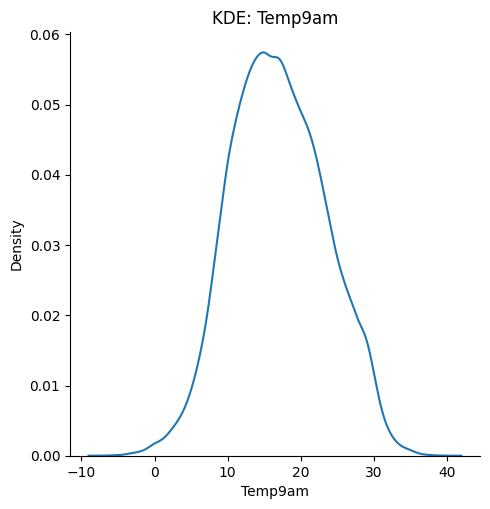

In [35]:
sns.displot(df, x='Temp9am', kind="kde")
plt.title('KDE: Temp9am')

Text(0.5, 1.0, 'KDE: Temp3pm')

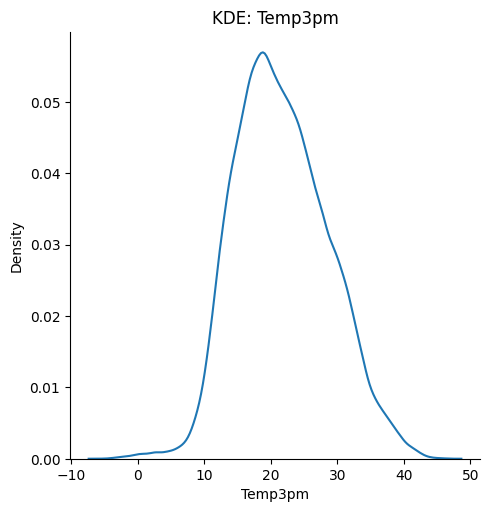

In [36]:
sns.displot(df, x='Temp3pm', kind="kde")
plt.title('KDE: Temp3pm')

Text(0.5, 1.0, 'KDE: Humidity3pm')

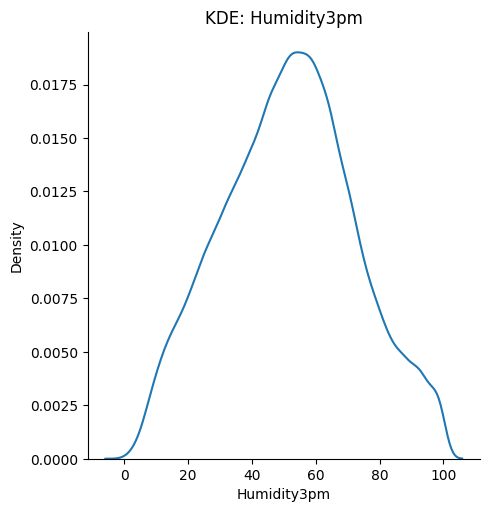

In [37]:
sns.displot(df, x='Humidity3pm', kind="kde")
plt.title('KDE: Humidity3pm')

Text(0.5, 1.0, 'KDE: MinTemp')

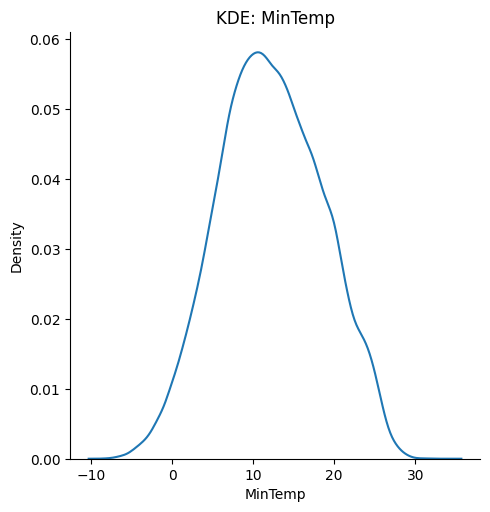

In [38]:
sns.displot(df, x='MinTemp', kind="kde")
plt.title('KDE: MinTemp')

Text(0.5, 1.0, 'KDE: MaxTemp')

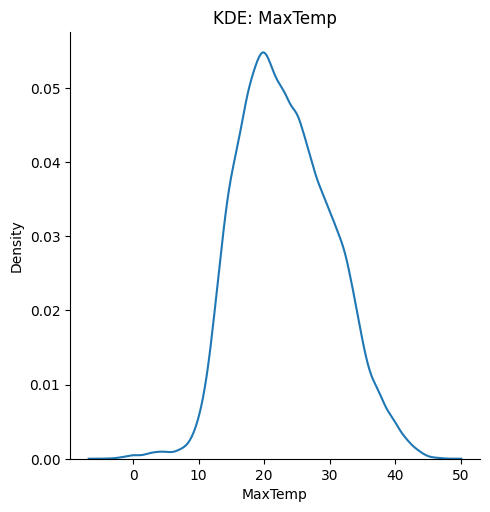

In [39]:
sns.displot(df, x='MaxTemp', kind="kde")
plt.title('KDE: MaxTemp')

In [40]:
df['MinTemp'] = df['MinTemp'].fillna(df['MinTemp'].mean())
df['MaxTemp'] = df['MaxTemp'].fillna(df['MaxTemp'].mean())

df['Humidity3pm'] = df['Humidity3pm'].fillna(df['Humidity3pm'].mean())
df['Temp9am'] = df['Temp9am'].fillna(df['Temp9am'].mean())
df['Temp3pm'] = df['Temp3pm'].fillna(df['Temp3pm'].mean())

Text(0.5, 1.0, 'KDE: Humidity9am')

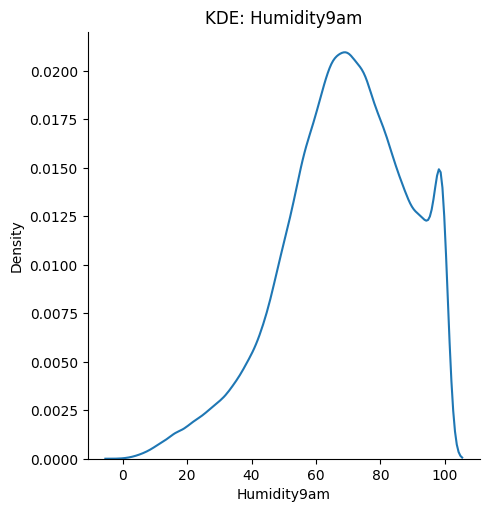

In [41]:
sns.displot(df, x='Humidity9am', kind="kde")
plt.title('KDE: Humidity9am')

In [42]:
df['Humidity9am'] = df['Humidity9am'].fillna(df['Humidity9am'].median())

In [43]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

In [44]:
num_df = df.select_dtypes(include=['number'])
cat_df = df.select_dtypes(include=['category', 'object'])

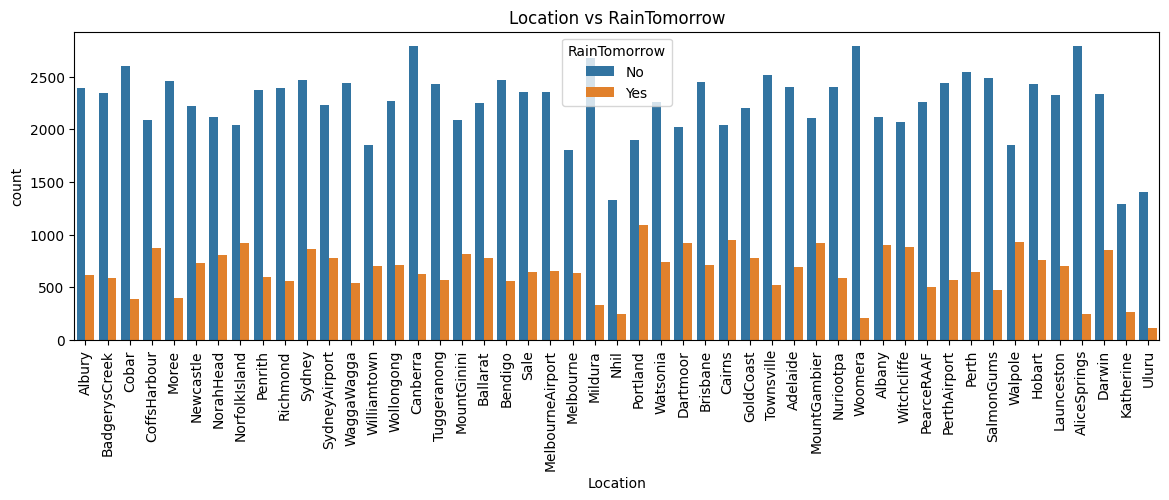

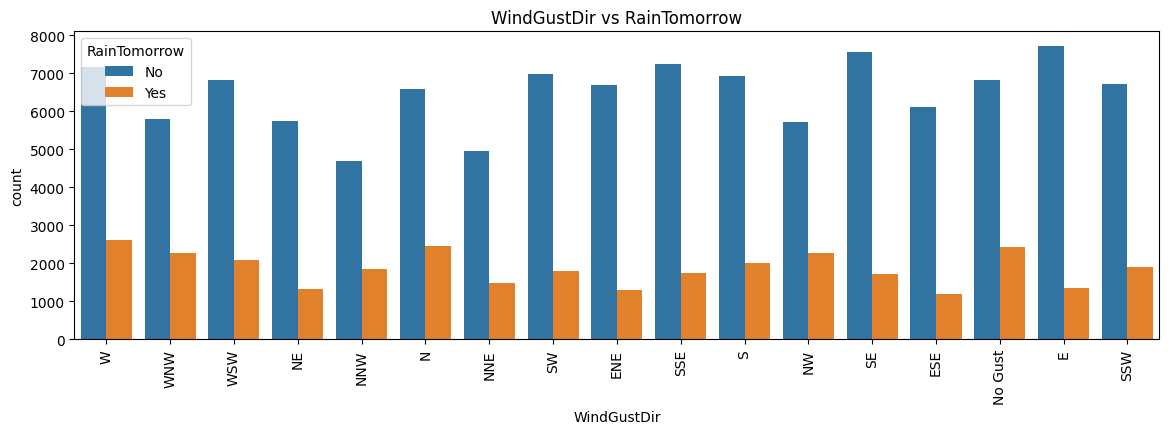

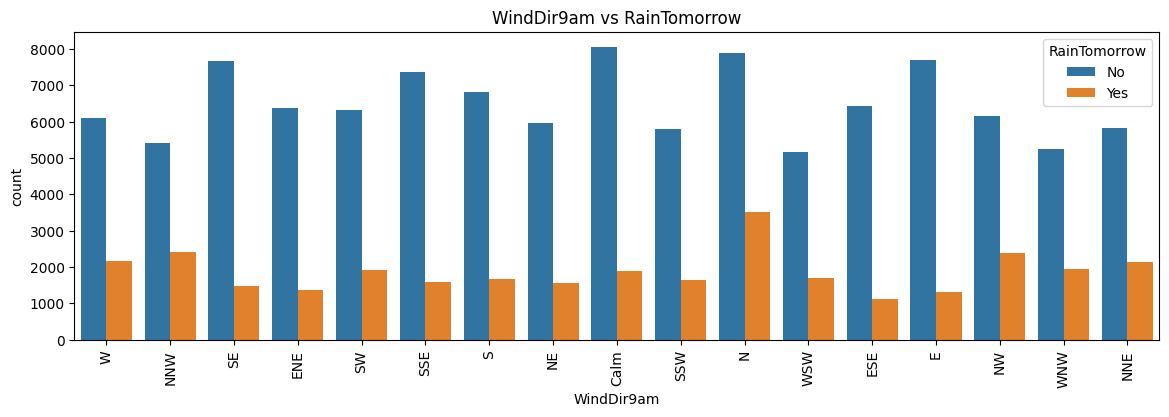

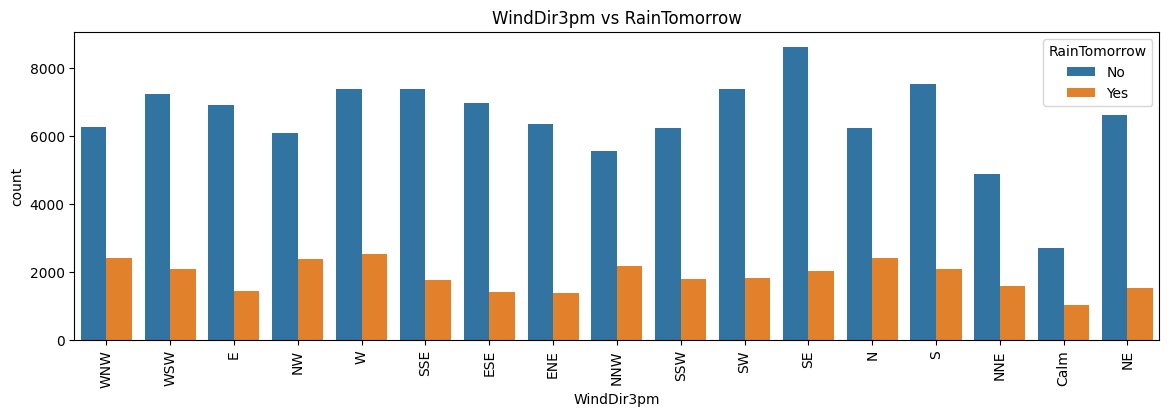

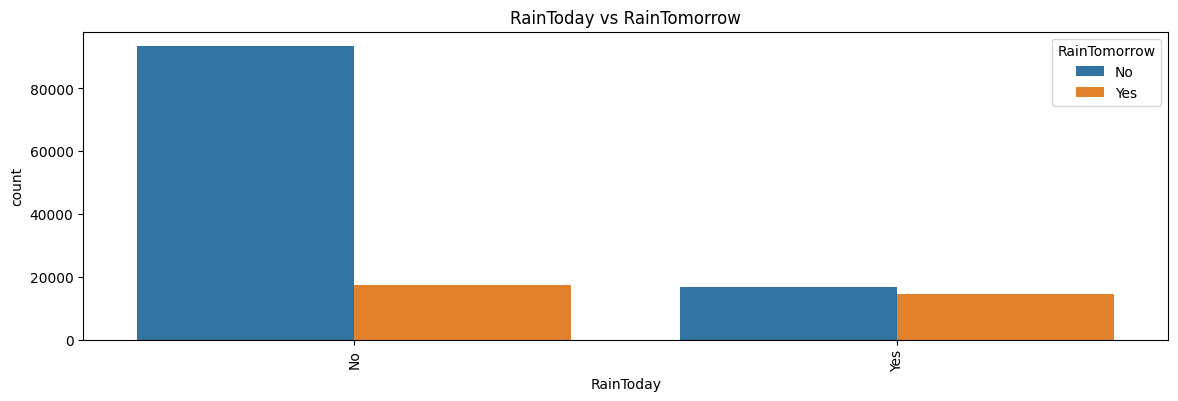

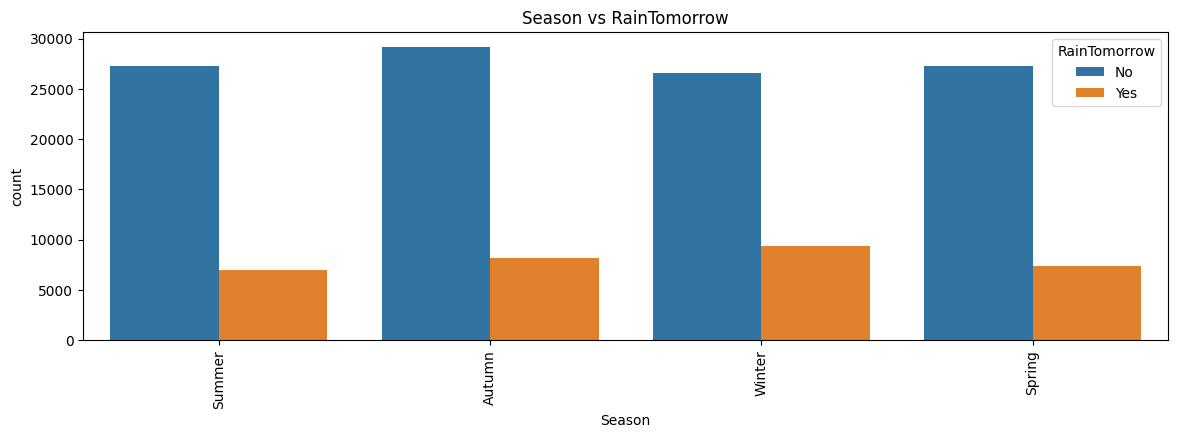

In [45]:
for col in cat_df.drop(columns=['RainTomorrow']):
    plt.figure(figsize=(14, 4))
    sns.countplot(data=df, x=col, hue='RainTomorrow')
    plt.title(f'{col} vs RainTomorrow')
    plt.xticks(rotation=90)
    plt.show()

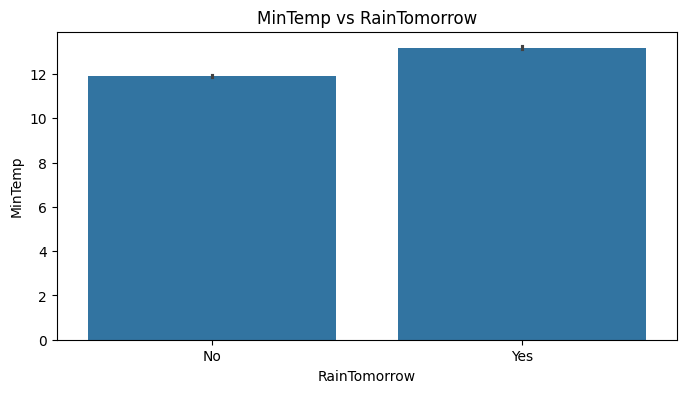

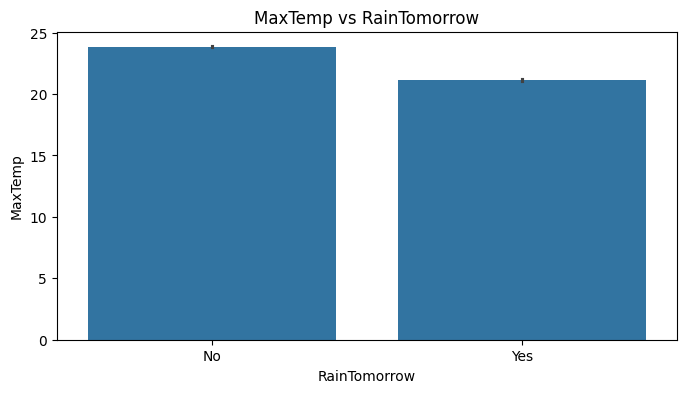

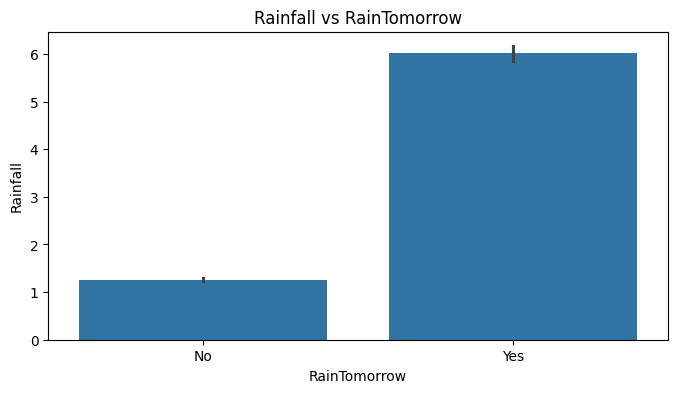

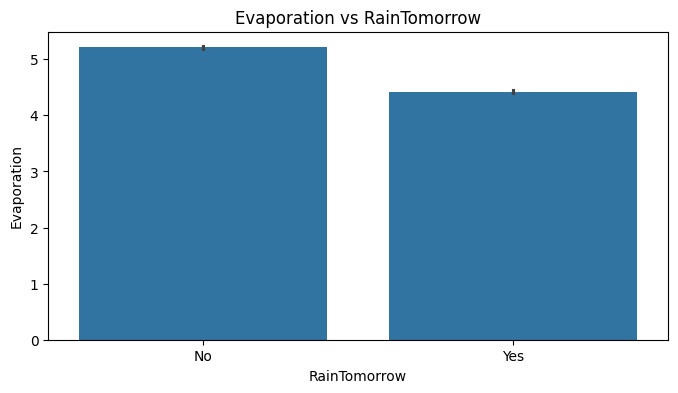

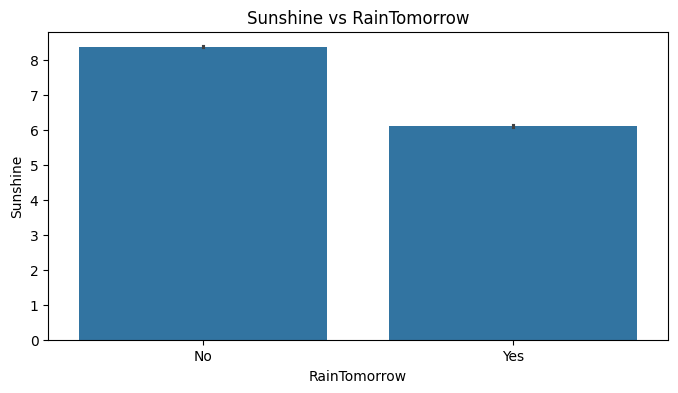

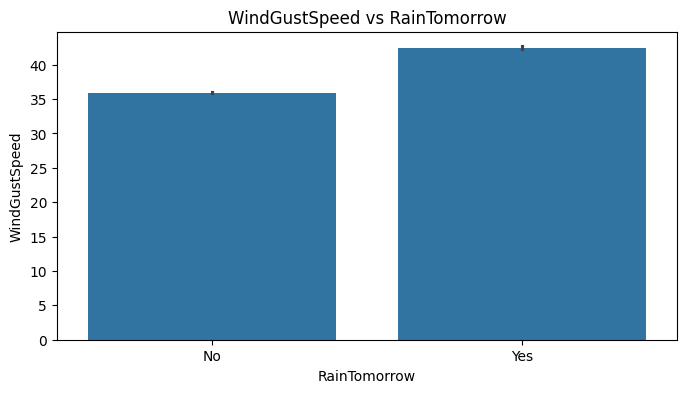

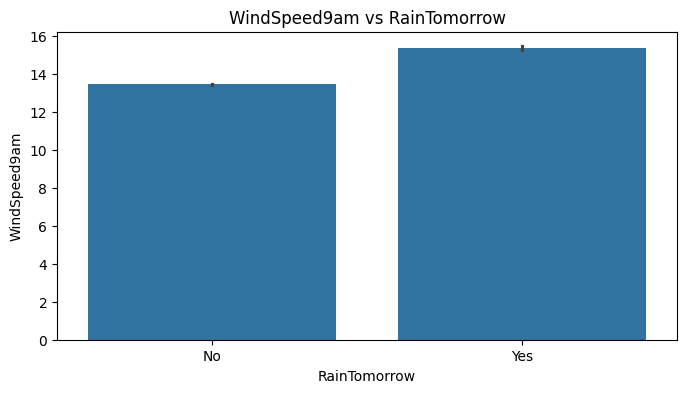

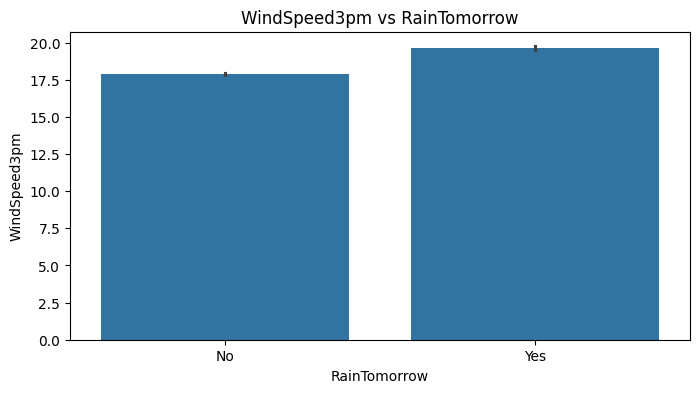

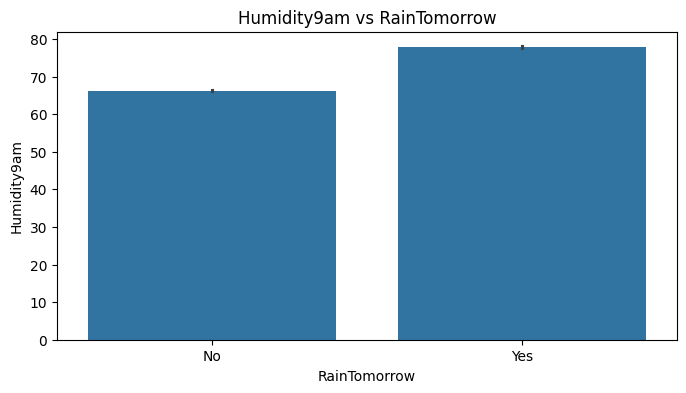

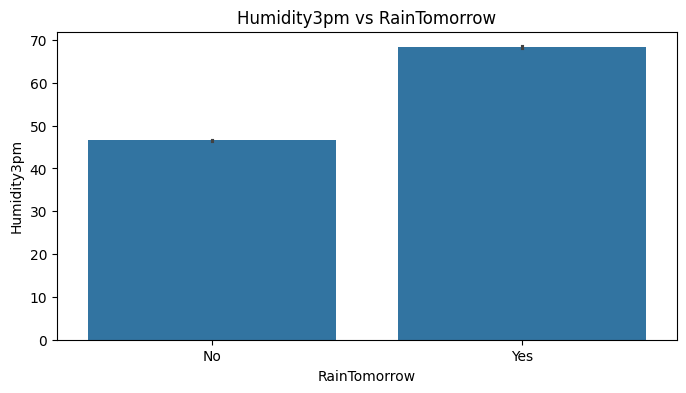

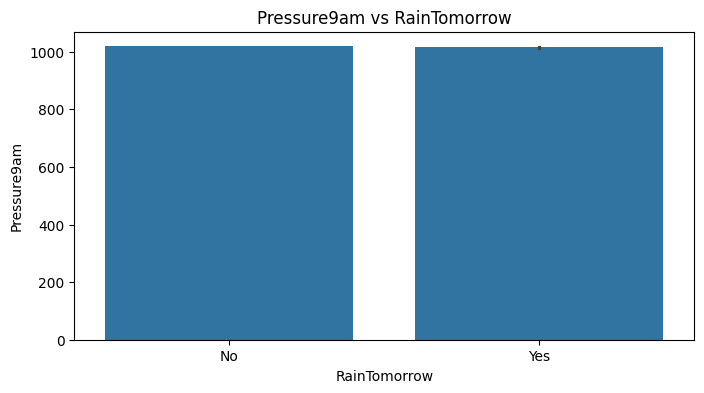

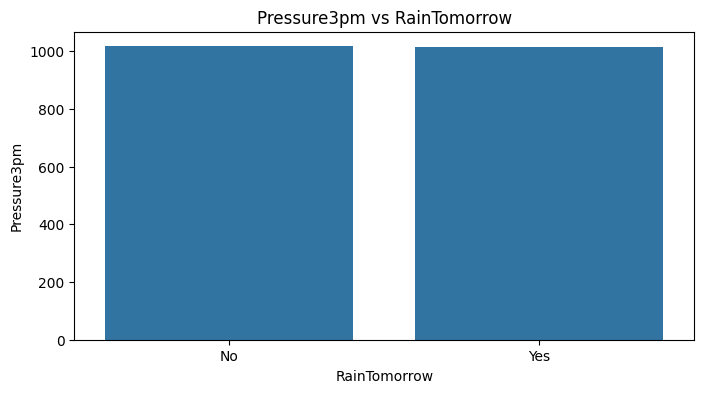

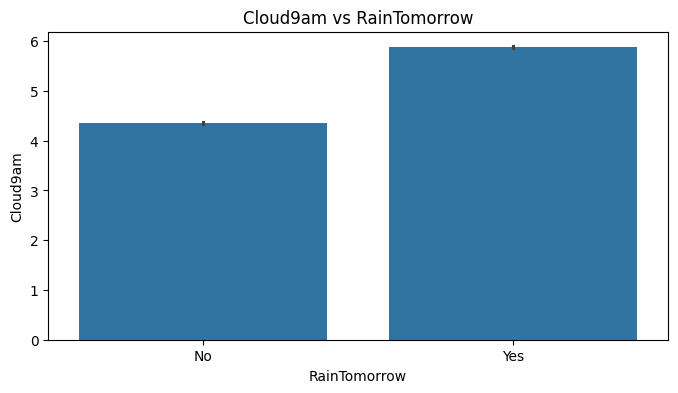

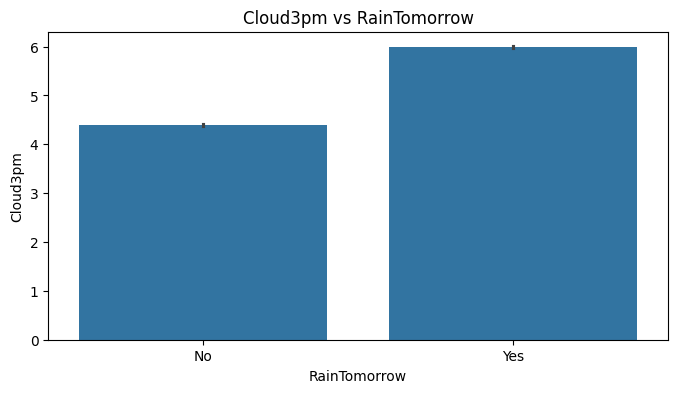

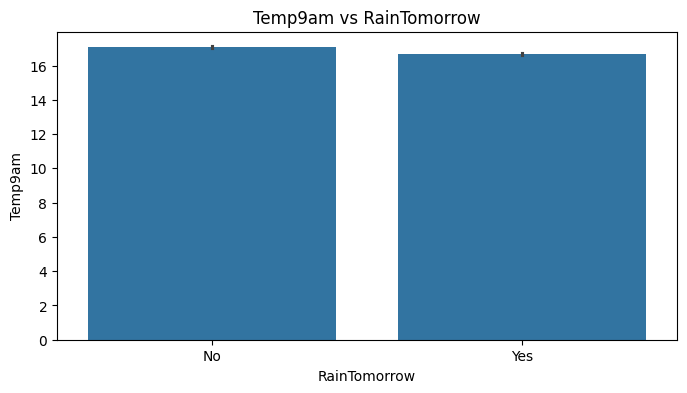

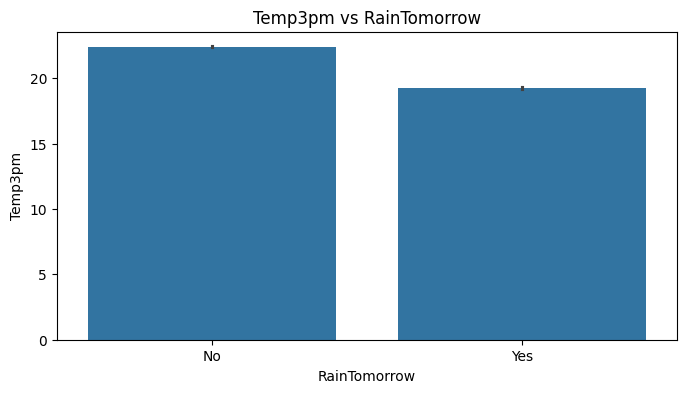

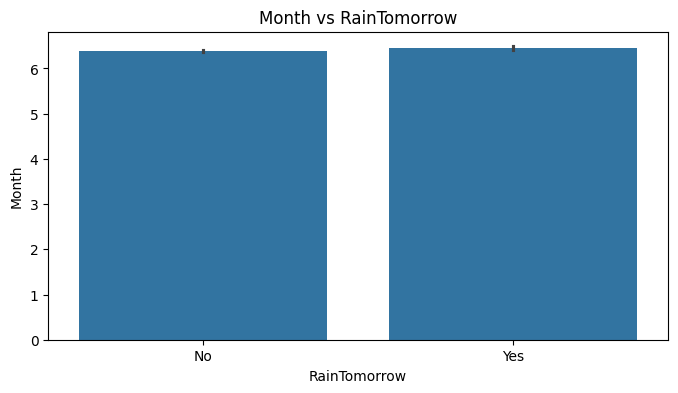

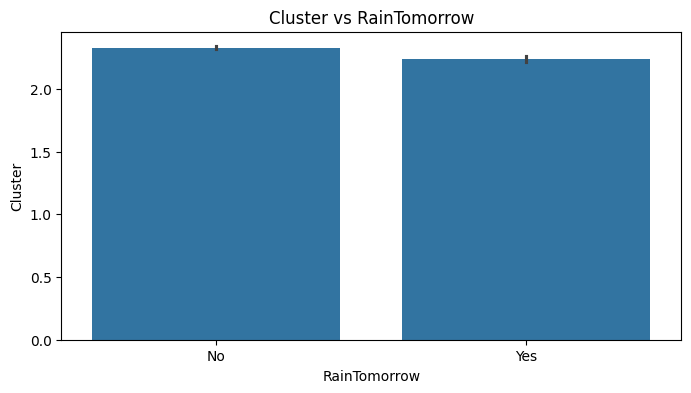

In [46]:
for col in num_df:
    plt.figure(figsize=(8, 4))
    sns.barplot(df, x='RainTomorrow', y=col)
    plt.title(f'{col} vs RainTomorrow')
    plt.show()

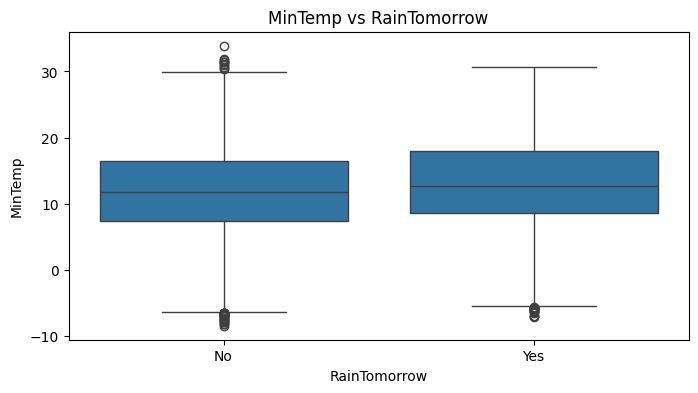

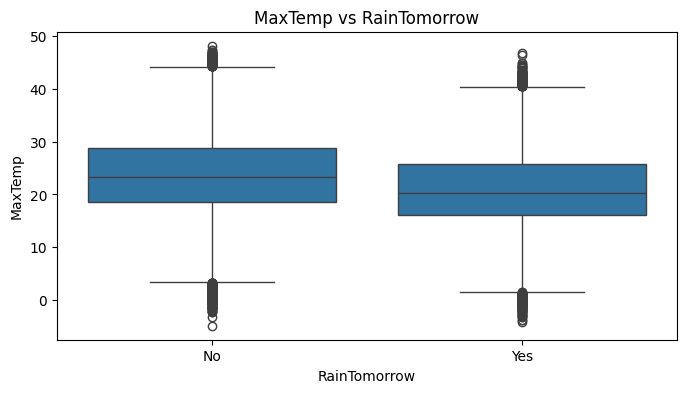

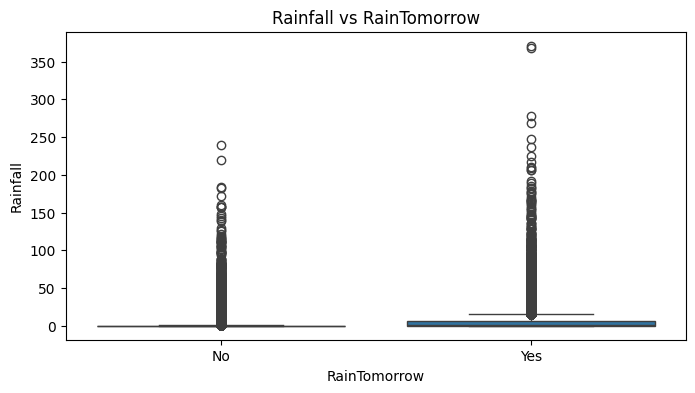

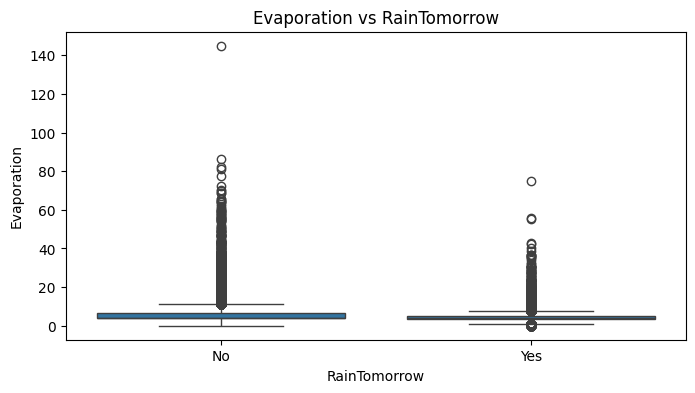

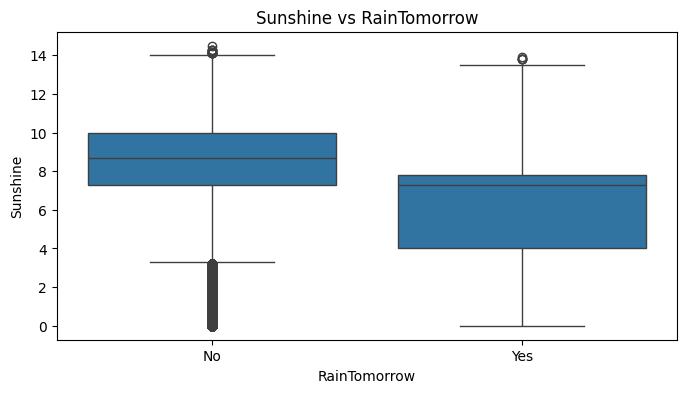

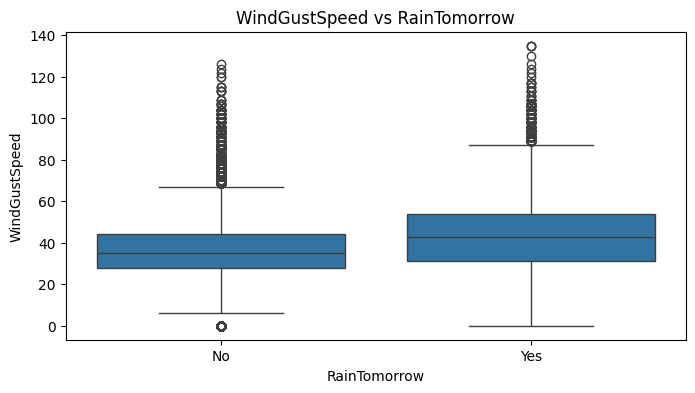

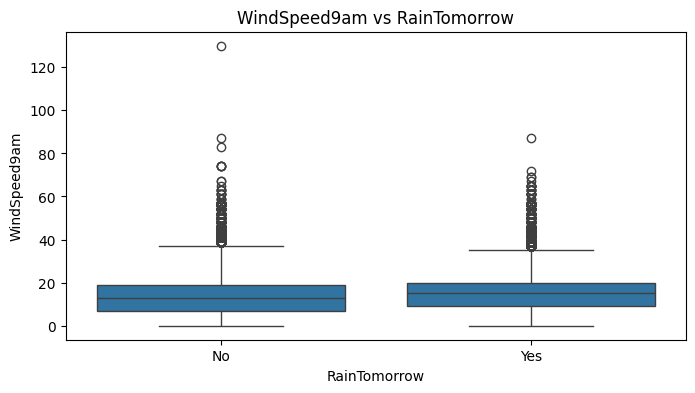

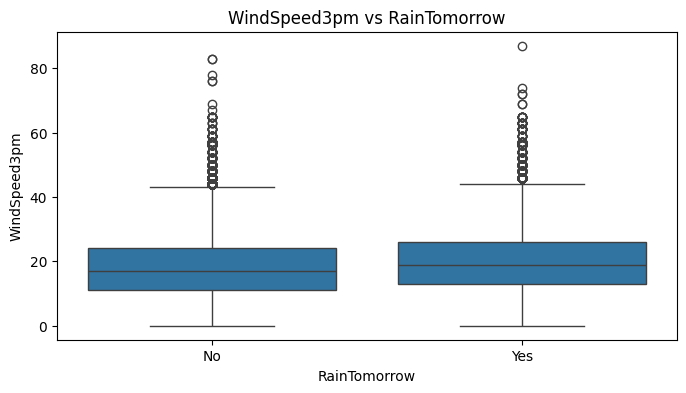

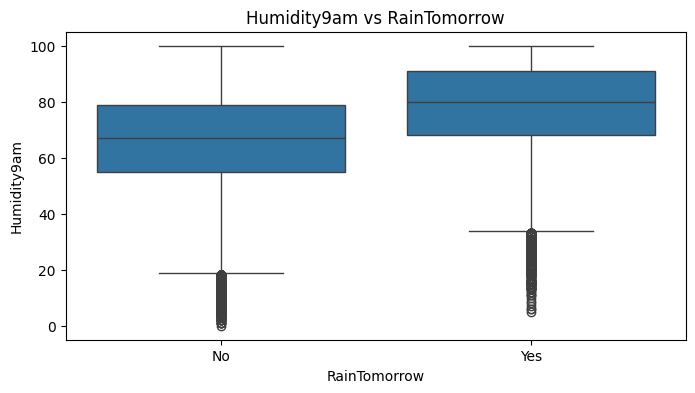

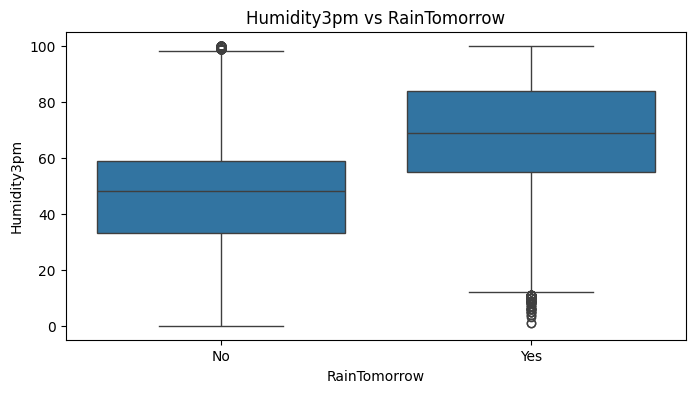

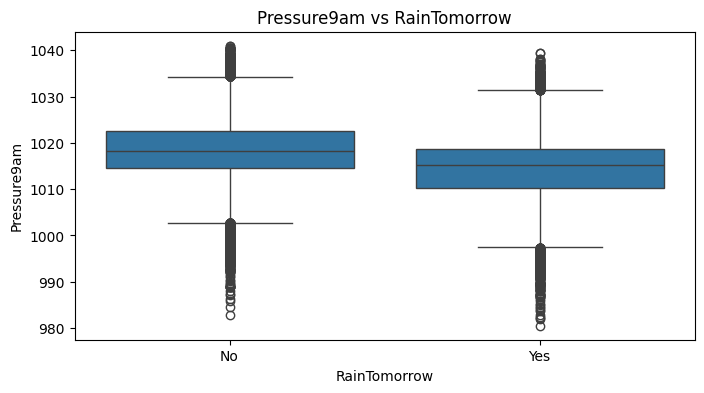

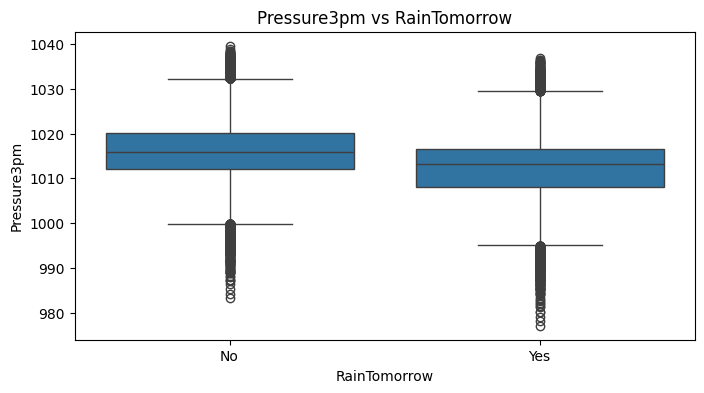

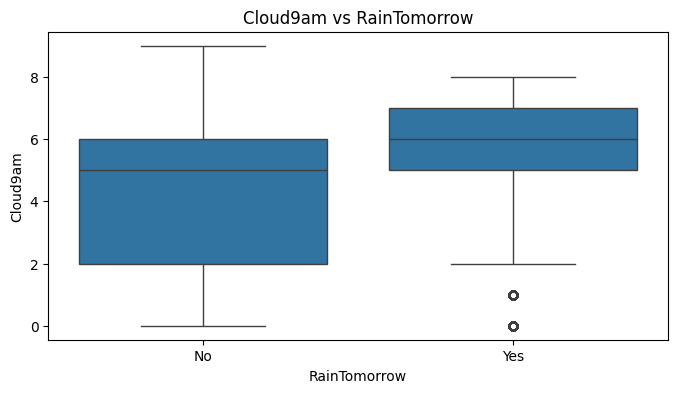

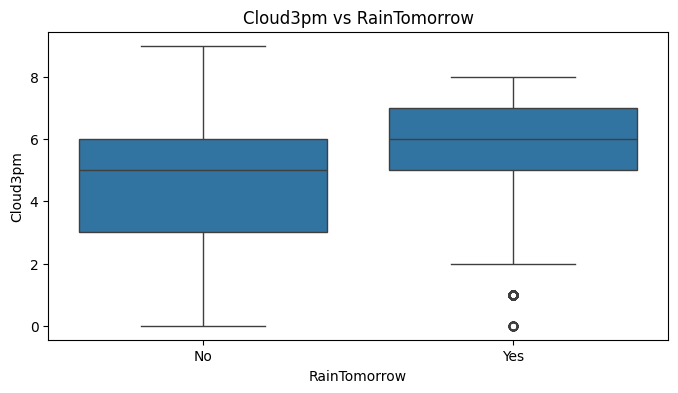

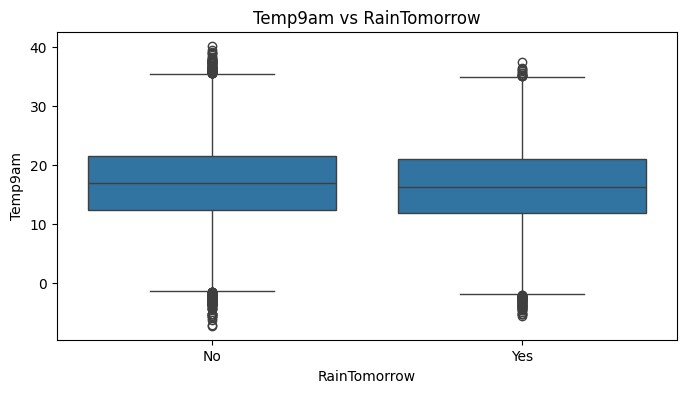

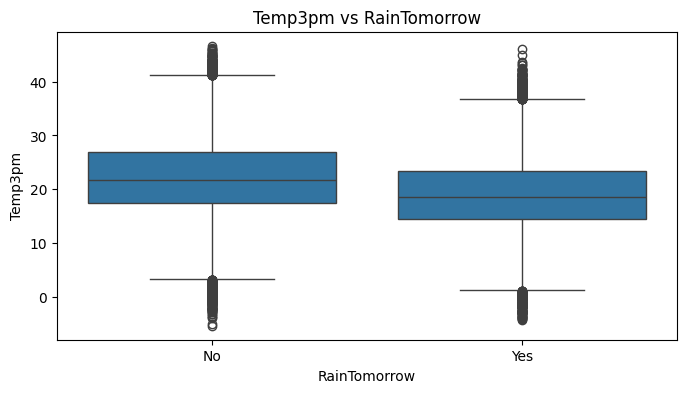

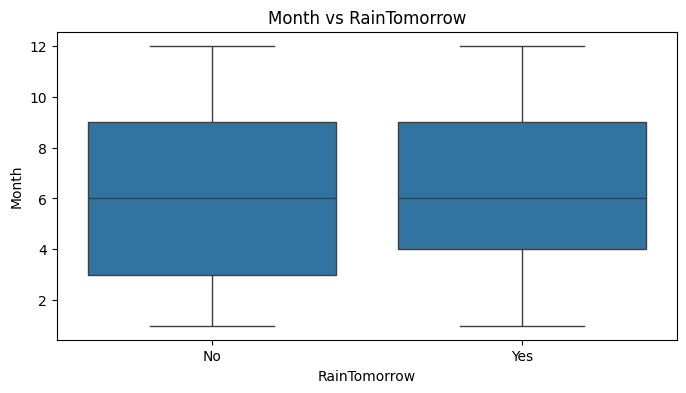

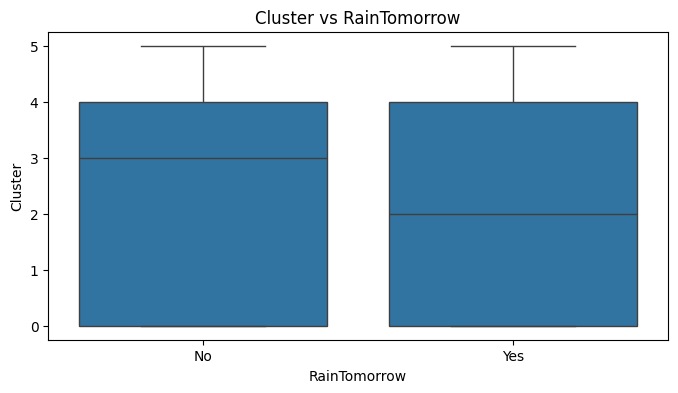

In [47]:
for col in num_df:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='RainTomorrow', y=col)
    plt.title(f'{col} vs RainTomorrow')
    plt.show()


<Axes: title={'center': 'Correlation Heatmap'}>

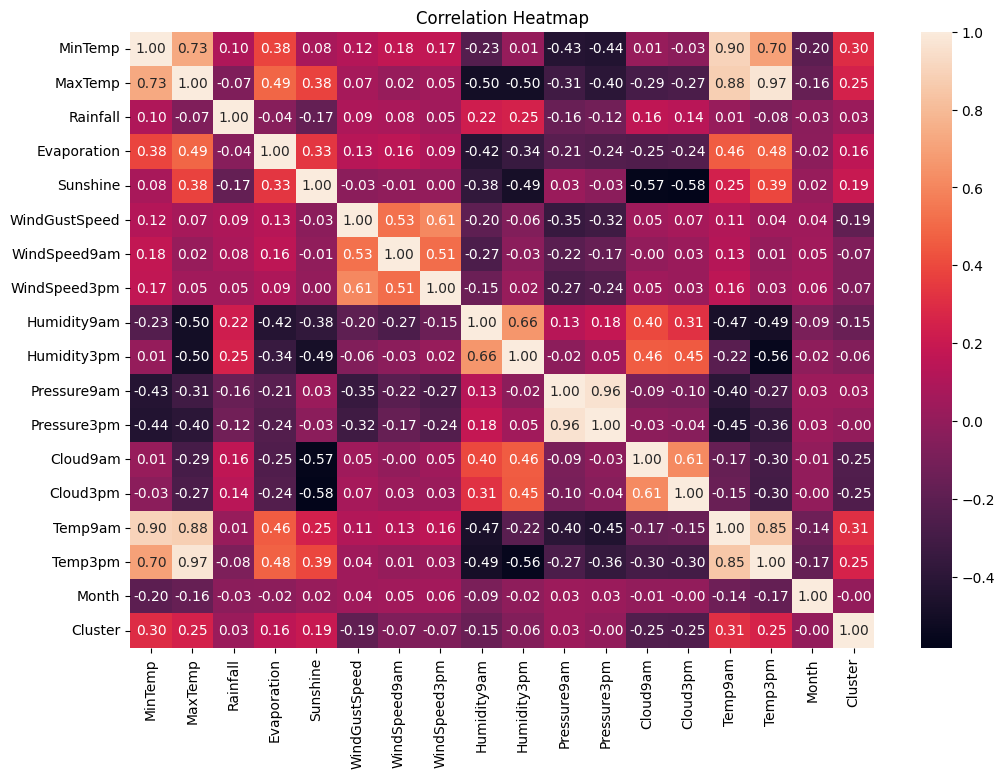

In [48]:
plt.figure(figsize=(12, 8))
plt.title('Correlation Heatmap')
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f')

In [49]:
skip_cols = ['Month']
for col in num_df.columns:
    if col in skip_cols:
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outliers capped → [{lower:.2f}, {upper:.2f}]")
    
    df[col] = df[col].clip(lower, upper)

num_df = df.select_dtypes(include=['number'])

MinTemp: 62 outliers capped → [-6.20, 30.60]
MaxTemp: 459 outliers capped → [2.45, 43.65]
Rainfall: 28523 outliers capped → [-0.90, 1.50]
Evaporation: 6829 outliers capped → [-0.40, 10.80]
Sunshine: 13124 outliers capped → [3.40, 13.80]
WindGustSpeed: 13030 outliers capped → [6.00, 70.00]
WindSpeed9am: 1738 outliers capped → [-11.00, 37.00]
WindSpeed3pm: 1271 outliers capped → [-8.50, 43.50]
Humidity9am: 1419 outliers capped → [18.00, 122.00]
Humidity3pm: 0 outliers capped → [-5.00, 107.00]
Pressure9am: 2704 outliers capped → [1001.05, 1034.25]
Pressure3pm: 2302 outliers capped → [998.40, 1032.00]
Cloud9am: 0 outliers capped → [-5.50, 14.50]
Cloud3pm: 0 outliers capped → [-1.50, 10.50]
Temp9am: 292 outliers capped → [-1.50, 35.30]
Temp3pm: 840 outliers capped → [2.30, 40.70]
Cluster: 0 outliers capped → [-6.00, 10.00]


In [50]:
df.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'Month', 'Season', 'Cluster'],
      dtype='object')

In [51]:
df['PressureChange'] = df['Pressure9am'] - df['Pressure3pm']

In [52]:
df['HumidityDrop'] = df['Humidity9am'] - df['Humidity3pm']

In [53]:
df['TempRange'] = df['MaxTemp'] - df['MinTemp']

In [54]:
df.rename(columns={'Cluster': 'LocationCluster'}, inplace=True)
df.drop(columns=['Location'], inplace=True)

In [55]:
#label Encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['RainTomorrow'])       

In [ ]:
#binary column
df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})

In [57]:
# 3. OHE for nominal categoricals
ohe_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Season']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

In [58]:
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [60]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [70]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [71]:
from sklearn.svm import SVC
clf = SVC(kernel='rbf', C=1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [72]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8284025750167094

In [73]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.91      0.86      0.89     22057
         Yes       0.60      0.71      0.65      6370

    accuracy                           0.83     28427
   macro avg       0.76      0.79      0.77     28427
weighted avg       0.84      0.83      0.83     28427

